# Notebook 09b: Inheritance-Mode Sensitivity Analysis

**Purpose:** Run identical crossing experiments under tetrasomic and disomic-averaged inheritance, with and without empirical SI leakage, across four management strategies. Decide whether the inheritance-mode question (Q1 in `Questions_for_Sven.md`) materially changes our conservation conclusions, or whether the strategy ranking is robust.

**Hypothesis to test:** *The relative ranking of strategies (Random < Optimized < Preservation < GFS-Preservation) is preserved across both inheritance modes and both leakage levels.* If true, the inheritance question is academic for management recommendations. If false, we must wait for Sven's answer before publishing.

**Experimental design:**

| Factor | Levels |
|---|---|
| Inheritance mode | `tetrasomic`, `disomic-averaged` |
| Per-gamete leakage | `0.0` (strict SI), `0.033` (matches Sven's L_hat=0.18 at pair level) |
| Strategy | `random`, `optimized`, `preservation`, `gfs_preservation` |
| Replicates per cell | 3 (parameter, scalable) |
| Generations | 3 (parameter, scalable) |
| Test bed | EO27 (53 individuals, MONITOR status, most-diverse focus EO) |

**Output metrics tracked per generation:**

- TP1: evenness `J`, compatible-pair fraction `P_compat`
- TP2: `mean_GFS`, `prop_AAAA`
- Allele dynamics: frequency variance, extinct allele count

**Outputs:** trajectory plots per inheritance × leakage × strategy, strategy-ranking robustness summary, and a final yes/no answer on whether inheritance mode changes management recommendations.


## 1. Setup

Load the LEPA biological population and select the test-bed EO.

In [1]:
import os
import sys
import pickle
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
np.random.seed(42)
random.seed(42)

sys.path.insert(0, "../src")
from polyploid_utils import (
    canonical, allele_frequencies, distance_from_equilibrium,
    enumerate_compatible_crosses, compute_optimal_weights,
    simulate_generation,
    evenness_J, p_compat,
    mean_gfs, prop_AAAA, genotype_class, gfs,
    L_HAT_GAMETE, L_HAT_PAIR,
)
from bl_constants import BL_COLORS, BL_ORDER

# Load biological-allele population (canonical post-synonymy view)
data = pickle.load(open("../data/population.pkl", "rb"))
print("Available population sizes (focus EOs):")
for eo in ["EO18", "EO25", "EO27", "EO67", "EO70", "EO76"]:
    pop = data["eo_populations"].get(eo, [])
    bl = data["eo_to_bl"].get(eo, {}).get("BL", "?")
    print(f"  {eo} ({bl}): {len(pop)} individuals")

print(f"\nAllele pool size: {len(data['allele_pool'])} biological alleles "
      f"({len(data['observed_bio_alleles'])} observed)")
print(f"L_HAT_GAMETE: {L_HAT_GAMETE} (per-gamete equivalent of Sven's pair-level L_hat={L_HAT_PAIR})")


Available population sizes (focus EOs):
  EO18 (BL5): 37 individuals
  EO25 (BL5): 53 individuals
  EO27 (BL4): 53 individuals
  EO67 (BL4): 36 individuals
  EO70 (BL2): 56 individuals
  EO76 (BL3): 74 individuals

Allele pool size: 27 biological alleles (21 observed)
L_HAT_GAMETE: 0.033 (per-gamete equivalent of Sven's pair-level L_hat=0.18)


## 2. Experiment Configuration

The full grid is `inheritance × leakage × strategy × replicate × generation`. Per-cell runtime scales roughly linearly with `len(pop)^2` (pair enumeration), `n_alleles` (optimizer), `n_generations`, and `n_trials`.

For EO27 (53 individuals, 21 observed alleles): expect ~5 seconds per generation, ~10 minutes total at the defaults.

To scale up after smoke-testing, increase `N_TRIALS` and/or `N_GENERATIONS`. To run on a different EO, change `TEST_EO`.


In [2]:
# ============================================================
# Experiment knobs
# ============================================================
TEST_EO        = "EO27"   # 53 indiv, MONITOR-status, most diverse focus EO
N_TRIALS       = 3        # replicates per (mode, leakage, strategy) cell
N_GENERATIONS  = 3        # generations to simulate per trial

# Factors -- the 2x2 sensitivity matrix
INHERITANCE_MODES = ["tetrasomic", "disomic-averaged"]
LEAKAGE_LEVELS    = [0.0, L_HAT_GAMETE]
STRATEGIES        = ["random", "optimized", "preservation", "gfs_preservation"]

# Strategy palette (distinct from BL palette to avoid color collision)
STRATEGY_COLORS = {
    "random":           "#666666",   # grey
    "optimized":        "#1f77b4",   # blue
    "preservation":     "#2ca02c",   # green
    "gfs_preservation": "#d62728",   # red
}
STRATEGY_LABELS = {
    "random":           "Random",
    "optimized":        "Optimized",
    "preservation":     "Preservation",
    "gfs_preservation": "GFS-Preservation",
}

# Allele preservation parameters (recalibrated post-synonymy per Critical_Review B.6)
RARE_MAX_CARRIERS    = 2
ELITE_FRAC           = 0.10
PRESERVATION_WEIGHT  = 10.0
GFS_WEIGHT           = 1.0          # GFS objective term weight per Crossing Plan 3.2.5

# Test bed
test_pop_full = data["eo_populations"][TEST_EO]
test_pool     = data["allele_pool"]
print(f"Test bed: {TEST_EO} -- {len(test_pop_full)} individuals, "
      f"{len(test_pool)}-allele pool")
print(f"Total experiment cells: "
      f"{len(INHERITANCE_MODES) * len(LEAKAGE_LEVELS) * len(STRATEGIES) * N_TRIALS} simulations "
      f"x {N_GENERATIONS} generations")


Test bed: EO27 -- 53 individuals, 27-allele pool
Total experiment cells: 48 simulations x 3 generations


## 3. Strategy Runner

A single function dispatches all four strategies. The `preservation` and `gfs_preservation` strategies share the same elite + mandatory rare-cross machinery; `gfs_preservation` additionally adds the GFS term to the optimizer's objective.

In [3]:
def run_strategy(pop, allele_pool, strategy, inheritance_mode, leakage,
                 n_generations, n_trials,
                 rare_max_carriers=RARE_MAX_CARRIERS,
                 elite_frac=ELITE_FRAC,
                 preservation_weight=PRESERVATION_WEIGHT,
                 gfs_weight=GFS_WEIGHT):
    """Run a strategy for `n_generations` over `n_trials` replicates.

    Returns a dict keyed by metric -> array of shape (n_trials, n_generations+1).
    Metrics: variance, extinct, J, P_compat, mean_gfs, prop_AAAA.
    """
    n_pop = len(pop)
    metrics = {k: np.zeros((n_trials, n_generations + 1))
               for k in ["variance", "extinct", "J", "P_compat",
                        "mean_gfs", "prop_AAAA"]}

    for trial in range(n_trials):
        current = list(pop)
        for gen in range(n_generations + 1):
            # ---- Record metrics for this generation ----
            d = distance_from_equilibrium(current, allele_pool)
            metrics["variance"][trial, gen]   = d["variance"]
            metrics["extinct"][trial, gen]    = d["extinct_alleles"]
            metrics["J"][trial, gen]          = evenness_J(current)
            metrics["P_compat"][trial, gen]   = p_compat(
                current, leakage=L_HAT_PAIR, inheritance_mode=inheritance_mode)
            metrics["mean_gfs"][trial, gen]   = mean_gfs(current)
            metrics["prop_AAAA"][trial, gen]  = prop_AAAA(current)

            # ---- Advance one generation if not at the end ----
            if gen >= n_generations:
                continue

            if strategy == "random":
                current = simulate_generation(
                    current, n_offspring=n_pop,
                    inheritance_mode=inheritance_mode, leakage=leakage,
                )
            else:
                # Build cross plan via optimizer
                cc, aem, gfs_arr = enumerate_compatible_crosses(
                    current, allele_pool,
                    inheritance_mode=inheritance_mode, leakage=leakage,
                )
                if len(cc) == 0:
                    # No compatible crosses at all (rare under leakage>0; can
                    # happen under strict SI in tiny pops). Drop a copy of the
                    # parent population unchanged.
                    current = list(current)
                    continue

                # Rare-allele indices for preservation penalty
                if strategy in ("preservation", "gfs_preservation"):
                    sorted_alleles = sorted(allele_pool)
                    carrier_counts = {a: 0 for a in allele_pool}
                    for g in current:
                        for a in set(g):
                            if a in carrier_counts:
                                carrier_counts[a] += 1
                    rare_idx = [i for i, a in enumerate(sorted_alleles)
                                if 0 < carrier_counts.get(a, 0) <= rare_max_carriers]
                else:
                    rare_idx = None

                # GFS term only for gfs_preservation
                gw = gfs_weight if strategy == "gfs_preservation" else 0.0
                weights, _ = compute_optimal_weights(
                    cc, aem, allele_pool, maxiter=200,
                    rare_allele_indices=rare_idx,
                    preservation_weight=preservation_weight,
                    expected_gfs_per_cross=gfs_arr if gw > 0 else None,
                    gfs_weight=gw,
                )
                plan = [(cc[k][0], cc[k][1], weights[k])
                        for k in range(len(cc)) if weights[k] > 1e-6]

                current = simulate_generation(
                    current, n_offspring=n_pop,
                    crossing_plan=plan,
                    allele_pool=allele_pool if strategy in ("preservation", "gfs_preservation") else None,
                    preserve_rare=(strategy in ("preservation", "gfs_preservation")),
                    elite_frac=elite_frac,
                    inheritance_mode=inheritance_mode, leakage=leakage,
                    gfs_filter=(strategy in ("preservation", "gfs_preservation")),
                    safety_net=False,  # honest comparison; Critical_Review D.5
                )
    return metrics


print("run_strategy() defined.")


run_strategy() defined.


## 4. Run the Sensitivity Grid

Loop over `(inheritance_mode, leakage, strategy)` and collect metrics. Results are stored in a nested dict for easy aggregation downstream.

In [4]:
import time

results = {}
start = time.time()
for mode in INHERITANCE_MODES:
    for L in LEAKAGE_LEVELS:
        for strategy in STRATEGIES:
            key = (mode, L, strategy)
            t0 = time.time()
            m = run_strategy(test_pop_full, test_pool, strategy,
                             inheritance_mode=mode, leakage=L,
                             n_generations=N_GENERATIONS, n_trials=N_TRIALS)
            elapsed = time.time() - t0
            results[key] = m
            print(f"  {mode:18s}  L={L:.3f}  {strategy:18s}  done in {elapsed:5.1f}s")
print(f"\nTotal wall time: {time.time() - start:.1f}s")


  tetrasomic          L=0.000  random              done in   0.1s


  tetrasomic          L=0.000  optimized           done in   0.7s


  tetrasomic          L=0.000  preservation        done in   0.7s


  tetrasomic          L=0.000  gfs_preservation    done in   0.9s
  tetrasomic          L=0.033  random              done in   0.0s


  tetrasomic          L=0.033  optimized           done in   1.1s


...

  disomic-averaged    L=0.000  gfs_preservation    done in   1.6s


  disomic-averaged    L=0.033  random              done in   0.3s


  disomic-averaged    L=0.033  optimized           done in   2.1s


  disomic-averaged    L=0.033  preservation        done in   1.9s


  disomic-averaged    L=0.033  gfs_preservation    done in   2.4s

Total wall time: 17.6s


## 5. TP1 Trajectories (Evenness x P_compat)

For each `(mode, leakage)` cell, plot per-strategy trajectories on the (J, P_compat) plane over generations. Strategy ranking visible as the relative positions and movement directions.

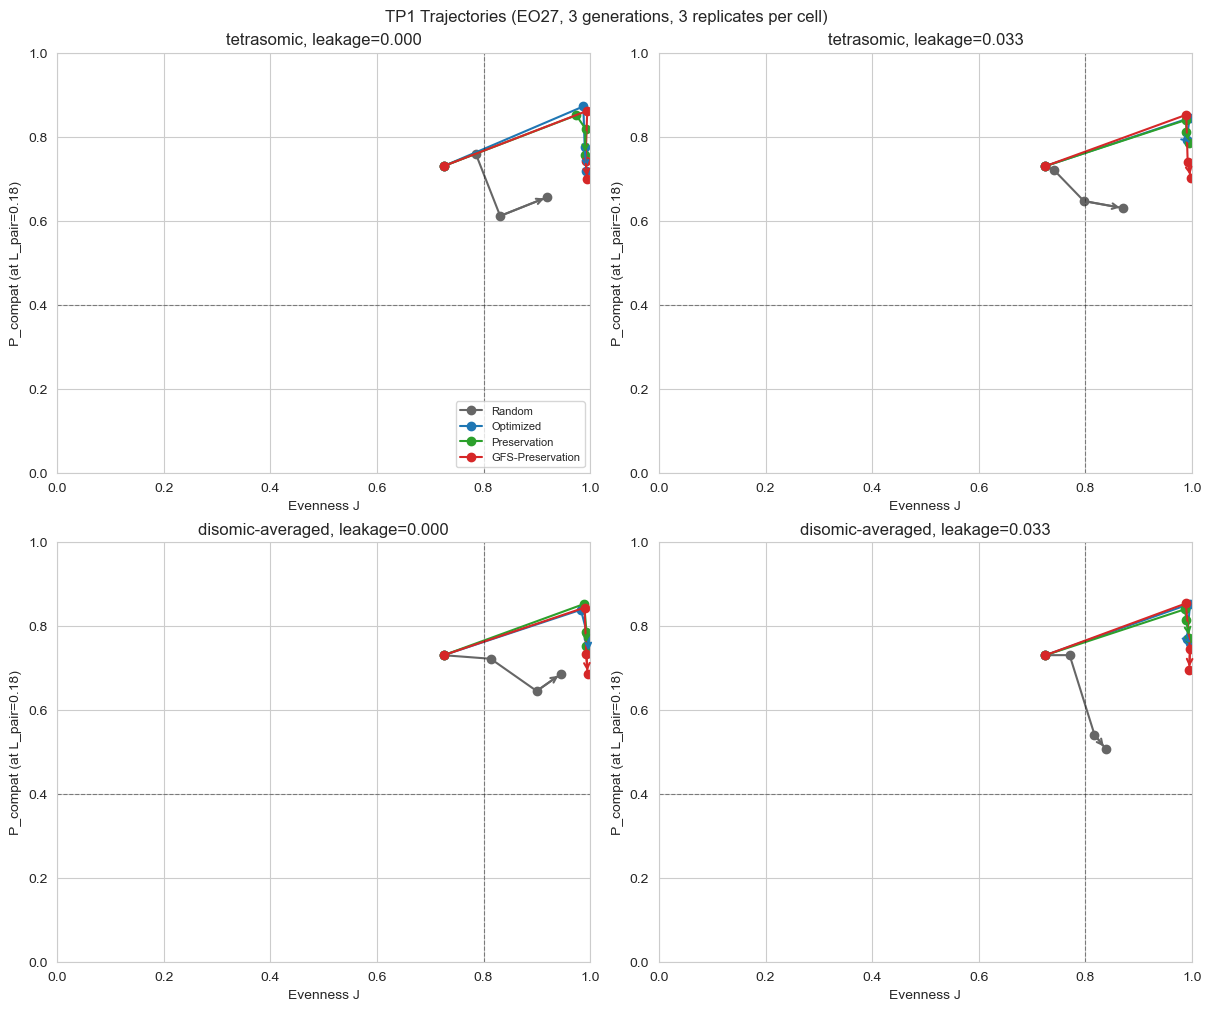

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), layout="constrained")
generations = np.arange(N_GENERATIONS + 1)

for row, mode in enumerate(INHERITANCE_MODES):
    for col, L in enumerate(LEAKAGE_LEVELS):
        ax = axes[row, col]
        for strategy in STRATEGIES:
            m = results[(mode, L, strategy)]
            j_mean        = m["J"].mean(axis=0)
            p_mean        = m["P_compat"].mean(axis=0)
            color         = STRATEGY_COLORS[strategy]
            # Trajectory line with arrowheads showing direction
            ax.plot(j_mean, p_mean, "-o", color=color, markersize=6,
                    label=STRATEGY_LABELS[strategy])
            ax.annotate("", xy=(j_mean[-1], p_mean[-1]),
                        xytext=(j_mean[-2], p_mean[-2]),
                        arrowprops=dict(arrowstyle="->", color=color, lw=1.5))

        # TP1 quadrant thresholds
        ax.axhline(0.40, color="black", linestyle="--", lw=0.8, alpha=0.4)
        ax.axvline(0.80, color="black", linestyle="--", lw=0.8, alpha=0.4)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xlabel("Evenness J")
        ax.set_ylabel("P_compat (at L_pair=0.18)")
        ax.set_title(f"{mode}, leakage={L:.3f}")
        if row == 0 and col == 0:
            ax.legend(loc="lower right", fontsize=8)

fig.suptitle(f"TP1 Trajectories ({TEST_EO}, {N_GENERATIONS} generations, {N_TRIALS} replicates per cell)",
             fontsize=12)
plt.show()


## 6. TP2 Trajectories (mean_GFS x prop_AAAA)

TP2 thresholds (CRITICAL): `mean_GFS < 0.667` AND `prop_AAAA > 0.30`. The goal is to drive trajectories away from the bottom-right (CRITICAL) quadrant.

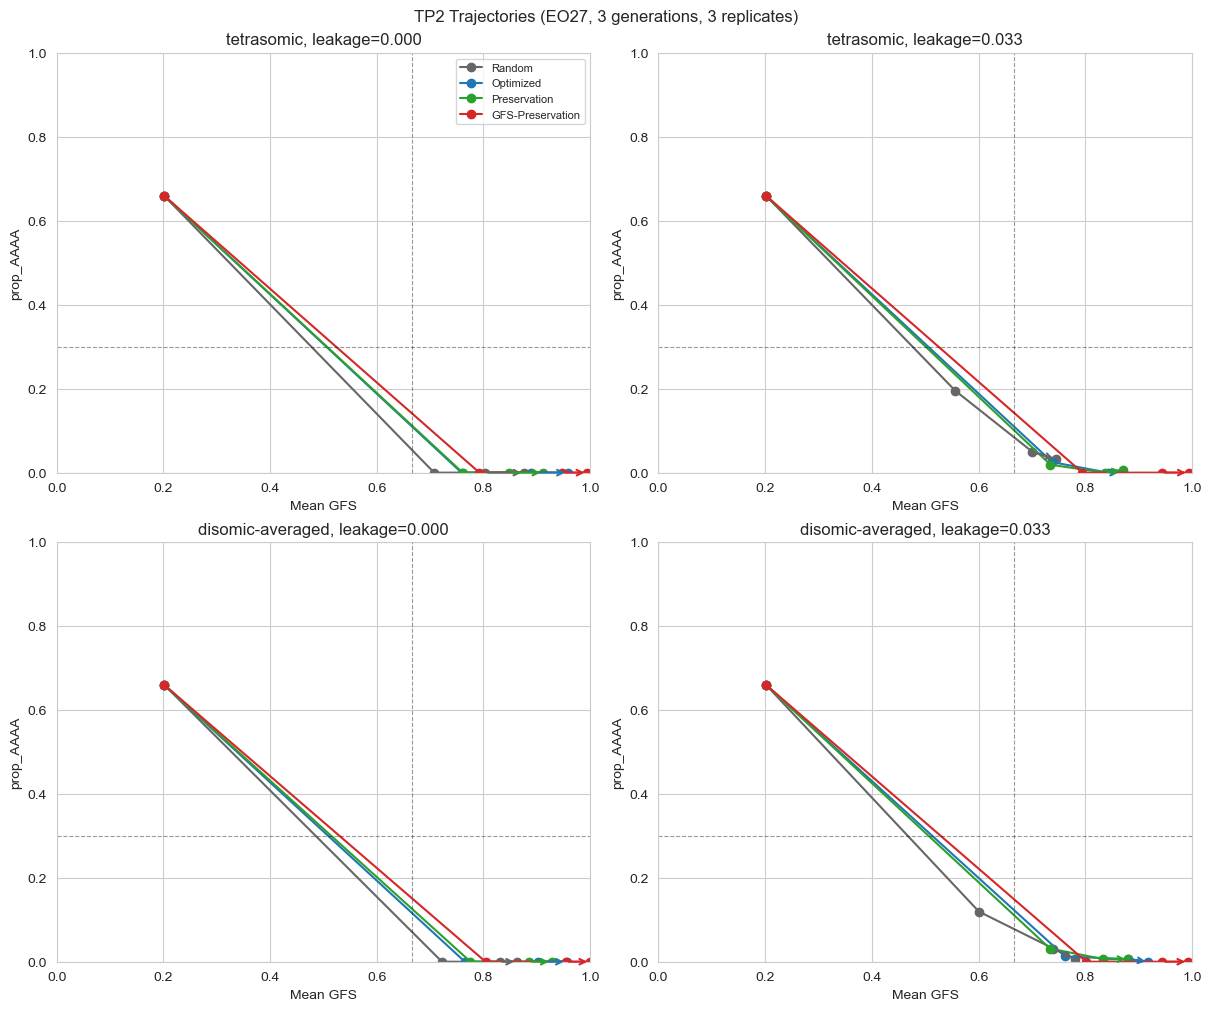

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), layout="constrained")

for row, mode in enumerate(INHERITANCE_MODES):
    for col, L in enumerate(LEAKAGE_LEVELS):
        ax = axes[row, col]
        for strategy in STRATEGIES:
            m = results[(mode, L, strategy)]
            mg_mean = m["mean_gfs"].mean(axis=0)
            pa_mean = m["prop_AAAA"].mean(axis=0)
            color = STRATEGY_COLORS[strategy]
            ax.plot(mg_mean, pa_mean, "-o", color=color, markersize=6,
                    label=STRATEGY_LABELS[strategy])
            ax.annotate("", xy=(mg_mean[-1], pa_mean[-1]),
                        xytext=(mg_mean[-2], pa_mean[-2]),
                        arrowprops=dict(arrowstyle="->", color=color, lw=1.5))

        # TP2 thresholds
        ax.axvline(0.667, color="black", linestyle="--", lw=0.8, alpha=0.4)
        ax.axhline(0.30,  color="black", linestyle="--", lw=0.8, alpha=0.4)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xlabel("Mean GFS")
        ax.set_ylabel("prop_AAAA")
        ax.set_title(f"{mode}, leakage={L:.3f}")
        if row == 0 and col == 0:
            ax.legend(loc="upper right", fontsize=8)

fig.suptitle(f"TP2 Trajectories ({TEST_EO}, {N_GENERATIONS} generations, {N_TRIALS} replicates)",
             fontsize=12)
plt.show()


## 7. Allele Frequency Variance and Extinction over Generations

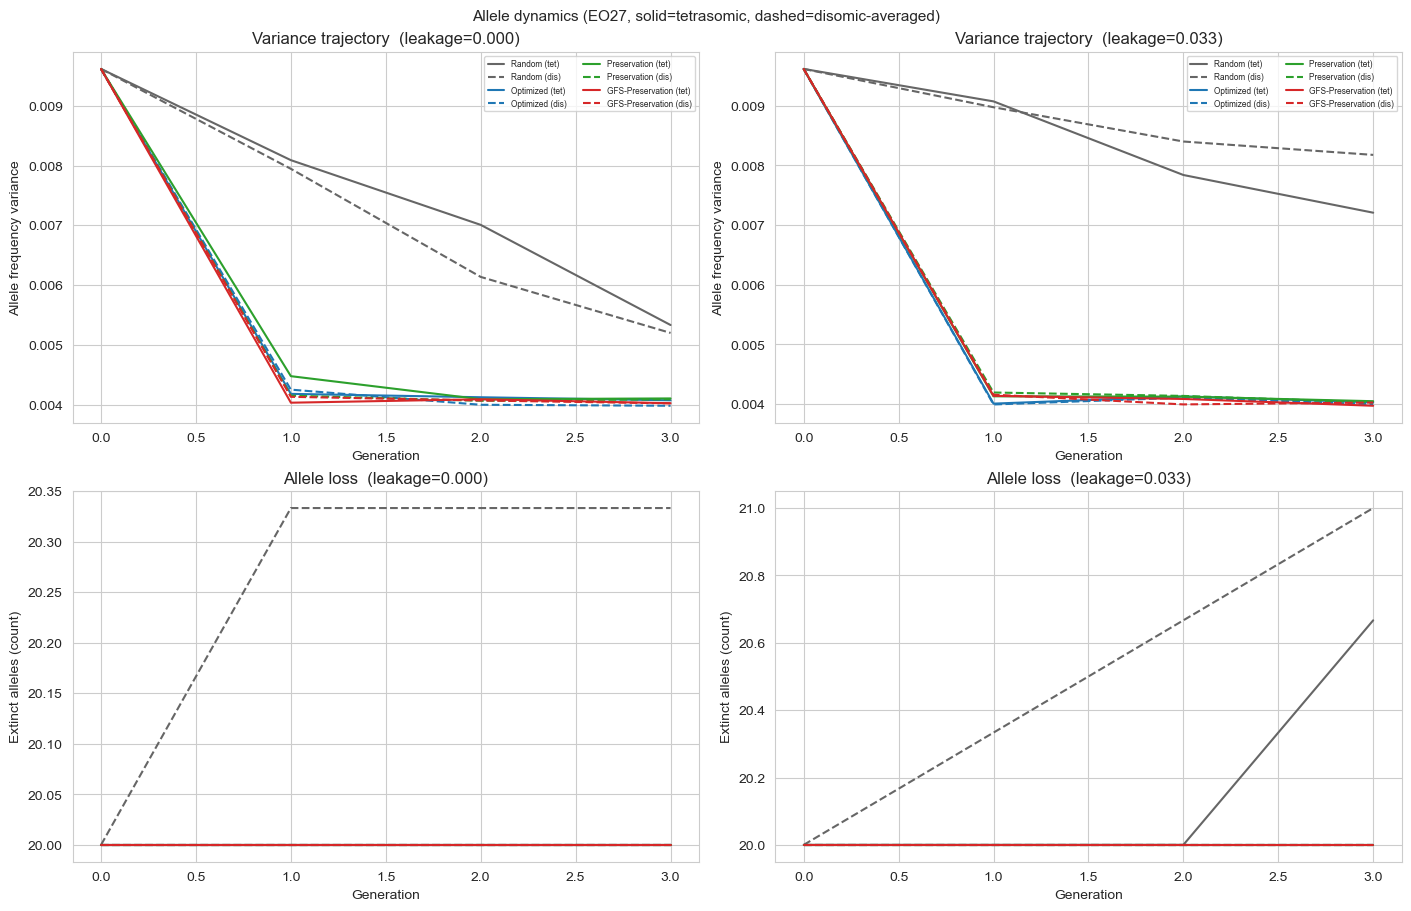

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), layout="constrained")

# Top row: variance trajectories (one panel per leakage); colored by strategy, linestyle by mode
for col, L in enumerate(LEAKAGE_LEVELS):
    ax = axes[0, col]
    for strategy in STRATEGIES:
        for mode, linestyle in [("tetrasomic", "-"), ("disomic-averaged", "--")]:
            m = results[(mode, L, strategy)]
            v_mean = m["variance"].mean(axis=0)
            color = STRATEGY_COLORS[strategy]
            label = f"{STRATEGY_LABELS[strategy]} ({mode[:3]})"
            ax.plot(generations, v_mean, linestyle, color=color, label=label, linewidth=1.5)
    ax.set_xlabel("Generation")
    ax.set_ylabel("Allele frequency variance")
    ax.set_title(f"Variance trajectory  (leakage={L:.3f})")
    ax.legend(fontsize=6, ncol=2)

# Bottom row: extinct alleles
for col, L in enumerate(LEAKAGE_LEVELS):
    ax = axes[1, col]
    for strategy in STRATEGIES:
        for mode, linestyle in [("tetrasomic", "-"), ("disomic-averaged", "--")]:
            m = results[(mode, L, strategy)]
            e_mean = m["extinct"].mean(axis=0)
            color = STRATEGY_COLORS[strategy]
            ax.plot(generations, e_mean, linestyle, color=color, linewidth=1.5)
    ax.set_xlabel("Generation")
    ax.set_ylabel("Extinct alleles (count)")
    ax.set_title(f"Allele loss  (leakage={L:.3f})")

fig.suptitle(f"Allele dynamics ({TEST_EO}, solid=tetrasomic, dashed=disomic-averaged)", fontsize=11)
plt.show()


## 8. Strategy Ranking Robustness

The headline question: *Is the strategy ranking preserved across inheritance modes and leakage levels?*

We summarise final-generation metrics per cell and check whether the rank order of strategies (by `mean_GFS` and by `prop_AAAA`) is the same across all four `(mode, leakage)` cells.

In [8]:
summary_rows = []
for mode in INHERITANCE_MODES:
    for L in LEAKAGE_LEVELS:
        for strategy in STRATEGIES:
            m = results[(mode, L, strategy)]
            summary_rows.append({
                "mode":             mode,
                "leakage":          L,
                "strategy":         STRATEGY_LABELS[strategy],
                "final_J":          m["J"][:, -1].mean(),
                "final_P_compat":   m["P_compat"][:, -1].mean(),
                "final_mean_GFS":   m["mean_gfs"][:, -1].mean(),
                "final_prop_AAAA":  m["prop_AAAA"][:, -1].mean(),
                "final_variance":   m["variance"][:, -1].mean(),
                "final_extinct":    m["extinct"][:, -1].mean(),
            })
summary = pd.DataFrame(summary_rows)
print(summary.to_string(index=False, float_format=lambda x: f"{x:.3f}"))


            mode  leakage         strategy  final_J  final_P_compat  final_mean_GFS  final_prop_AAAA  final_variance  final_extinct
      tetrasomic    0.000           Random    0.919           0.656           0.876            0.000           0.005         20.000
      tetrasomic    0.000        Optimized    0.993           0.720           0.958            0.000           0.004         20.000
      tetrasomic    0.000     Preservation    0.990           0.757           0.912            0.000           0.004         20.000
      tetrasomic    0.000 GFS-Preservation    0.995           0.699           0.995            0.000           0.004         20.000
      tetrasomic    0.033           Random    0.870           0.631           0.745            0.031           0.007         20.667
      tetrasomic    0.033        Optimized    0.995           0.788           0.867            0.000           0.004         20.000
      tetrasomic    0.033     Preservation    0.994           0.787         

In [9]:
# Rank strategies (higher mean_GFS = better) per (mode, leakage) cell
print("Strategy ranking by final mean_GFS (best -> worst):")
print()
for mode in INHERITANCE_MODES:
    for L in LEAKAGE_LEVELS:
        sub = summary[(summary["mode"] == mode) & (summary["leakage"] == L)]
        ordered = sub.sort_values("final_mean_GFS", ascending=False)
        ranking = " > ".join(ordered["strategy"].tolist())
        print(f"  {mode:18s}  L={L:.3f}: {ranking}")

print()
print("Strategy ranking by final prop_AAAA (lower = better -- fewer dead-ends):")
print()
for mode in INHERITANCE_MODES:
    for L in LEAKAGE_LEVELS:
        sub = summary[(summary["mode"] == mode) & (summary["leakage"] == L)]
        ordered = sub.sort_values("final_prop_AAAA", ascending=True)
        ranking = " > ".join(ordered["strategy"].tolist())
        print(f"  {mode:18s}  L={L:.3f}: {ranking}")


Strategy ranking by final mean_GFS (best -> worst):

  tetrasomic          L=0.000: GFS-Preservation > Optimized > Preservation > Random
  tetrasomic          L=0.033: GFS-Preservation > Preservation > Optimized > Random
  disomic-averaged    L=0.000: GFS-Preservation > Optimized > Preservation > Random
  disomic-averaged    L=0.033: GFS-Preservation > Optimized > Preservation > Random

Strategy ranking by final prop_AAAA (lower = better -- fewer dead-ends):

  tetrasomic          L=0.000: Random > Optimized > Preservation > GFS-Preservation
  tetrasomic          L=0.033: Optimized > GFS-Preservation > Preservation > Random
  disomic-averaged    L=0.000: Random > Optimized > Preservation > GFS-Preservation
  disomic-averaged    L=0.033: Optimized > GFS-Preservation > Random > Preservation


## 9. Headline Finding

Read the rankings above:

- **If all four `(mode, leakage)` cells produce the same ranking**: the strategy choice is robust to the inheritance-mode question. We can publish results without bracketing on Q1.
- **If rankings flip between modes**: we need Sven's answer to Q1 before locking in a recommendation.
- **If rankings flip between leakage levels but not between modes**: the conservation framing depends on Sven's L_hat calibration but not on inheritance mode.

Also worth checking: do the *absolute differences* between strategies shrink under disomic-averaged inheritance? If so, the per-individual variation that disomic introduces dilutes the strategy signal -- which would affect statistical power for any field deployment.


In [10]:
# Quantify rank stability
def ranking(sub_summary, key, ascending):
    return tuple(sub_summary.sort_values(key, ascending=ascending)["strategy"].tolist())

ranks_gfs = {}
ranks_aaaa = {}
for mode in INHERITANCE_MODES:
    for L in LEAKAGE_LEVELS:
        sub = summary[(summary["mode"] == mode) & (summary["leakage"] == L)]
        ranks_gfs[(mode, L)]  = ranking(sub, "final_mean_GFS",  ascending=False)
        ranks_aaaa[(mode, L)] = ranking(sub, "final_prop_AAAA", ascending=True)

print("=" * 70)
print("Rank stability check")
print("=" * 70)
gfs_set = set(ranks_gfs.values())
aaaa_set = set(ranks_aaaa.values())
if len(gfs_set) == 1:
    print(f"  mean_GFS ranking: STABLE across all 4 cells -- {ranks_gfs[(INHERITANCE_MODES[0], LEAKAGE_LEVELS[0])]}")
else:
    print(f"  mean_GFS ranking: VARIES across cells ({len(gfs_set)} distinct rankings)")
    for k, r in ranks_gfs.items():
        print(f"    {k}: {r}")

if len(aaaa_set) == 1:
    print(f"  prop_AAAA ranking: STABLE across all 4 cells -- {ranks_aaaa[(INHERITANCE_MODES[0], LEAKAGE_LEVELS[0])]}")
else:
    print(f"  prop_AAAA ranking: VARIES across cells ({len(aaaa_set)} distinct rankings)")
    for k, r in ranks_aaaa.items():
        print(f"    {k}: {r}")

print()
# Average effect-size of inheritance mode (final mean_GFS difference, holding strategy+leakage fixed)
diffs = []
for L in LEAKAGE_LEVELS:
    for s in STRATEGIES:
        tet = float(summary[(summary["mode"] == "tetrasomic") & (summary["leakage"] == L) &
                            (summary["strategy"] == STRATEGY_LABELS[s])]["final_mean_GFS"].iloc[0])
        dis = float(summary[(summary["mode"] == "disomic-averaged") & (summary["leakage"] == L) &
                            (summary["strategy"] == STRATEGY_LABELS[s])]["final_mean_GFS"].iloc[0])
        diffs.append(dis - tet)
print(f"Mean inheritance-mode effect on final_mean_GFS (disomic - tetrasomic): "
      f"{np.mean(diffs):+.4f} +/- {np.std(diffs):.4f}")
print("(positive = disomic-averaged gives higher GFS on average)")


Rank stability check
  mean_GFS ranking: VARIES across cells (2 distinct rankings)
    ('tetrasomic', 0.0): ('GFS-Preservation', 'Optimized', 'Preservation', 'Random')
    ('tetrasomic', 0.033): ('GFS-Preservation', 'Preservation', 'Optimized', 'Random')
    ('disomic-averaged', 0.0): ('GFS-Preservation', 'Optimized', 'Preservation', 'Random')
    ('disomic-averaged', 0.033): ('GFS-Preservation', 'Optimized', 'Preservation', 'Random')
  prop_AAAA ranking: VARIES across cells (3 distinct rankings)
    ('tetrasomic', 0.0): ('Random', 'Optimized', 'Preservation', 'GFS-Preservation')
    ('tetrasomic', 0.033): ('Optimized', 'GFS-Preservation', 'Preservation', 'Random')
    ('disomic-averaged', 0.0): ('Random', 'Optimized', 'Preservation', 'GFS-Preservation')
    ('disomic-averaged', 0.033): ('Optimized', 'GFS-Preservation', 'Random', 'Preservation')

Mean inheritance-mode effect on final_mean_GFS (disomic - tetrasomic): +0.0126 +/- 0.0198
(positive = disomic-averaged gives higher GFS on av

## 10. Interpretation

The cell above prints either `STABLE` or `VARIES` for the two ranking metrics. If both are STABLE, the management recommendations from this model are robust to the inheritance question Q1 -- we can proceed without bracketing.

If either VARIES, the next step is to widen the comparison (more EOs, more trials, more generations) and flag the result in the report to Sven.

Also worth noting: the per-cell effect size of inheritance mode (last printout) gives a sense of how much disomic-averaged shifts the answer. Differences of `0.01-0.03` in mean_GFS are within typical trial-to-trial noise; differences of `0.05-0.10` would represent a real shift in the conservation diagnostic.
